In [11]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants

%matplotlib widget
# pybamm.set_logging_level("INFO")
# plt.rcParams.update({'font.size': 14})
pybamm.settings.max_smoothing = 0.2



c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [12]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [13]:
SOC_name = '100A'
SOC_0 = 1 #str(int(SOC_0*100))
Q_nom = 4.6

if SOC_name == '100A':
    t_end = 80
elif SOC_name =='100B':
    t_end = 53
else:
    t_end =  15*60

# load data import ESC data from file
raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
# if SOC_name =='100F':
    # data = raw_data[['Time (s)', 'Voltage (V)', 'Thermocouple_2', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
# else:
data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
# data['Cell Temperature'][data['Cell Temperature']>140] = None
# data.interpolate(inplace=True)
data['Current Shunt'] = -data['Current Shunt']
data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
data['Force'] = data['Force']*9.81
data['Cell Temperature'][data['Cell Temperature']>140] = None
data.interpolate(inplace=True)
df_labels = ['t', 'V', 'Temp','I', 'F']
data.set_axis(df_labels, axis=1, inplace=True)
data['I_C'] = data.I/Q_nom 
AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
data.reset_index(drop=True, inplace=True)
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'ESC_100ASOC_full.csv'

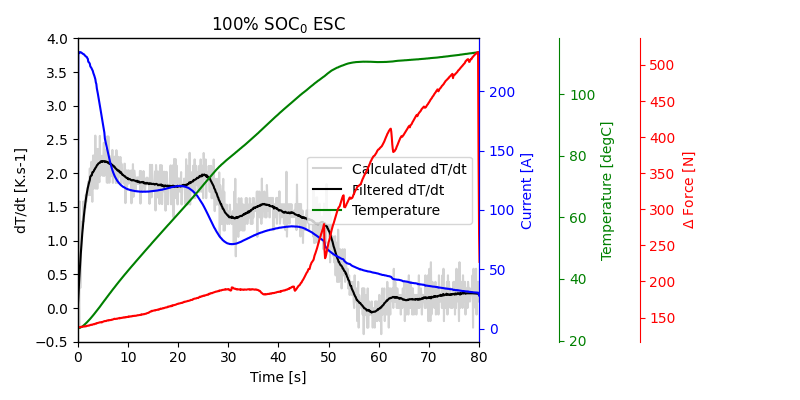

In [ ]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 50,3)

# plot 
fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
# ax = ax.flatten()
p1, = ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
p2, = ax.plot(data.t[0:-1], dT_filtered, color = 'k', label = "Filtered dT/dt")
ax.set_ylabel("dT/dt [K.s-1]")
ax.set_xlabel("Time [s]")
ax.set_ylim([-0.5, 4])
ax.set_xlim([0,t_end])

ax2 = ax.twinx()
p4, = ax2.plot(data.t, data.I, color = 'b', label = "Current")
ax2.set_ylabel('Current [A]')
ax2.yaxis.label.set_color(p4.get_color())
ax2.tick_params(axis='y', colors=p4.get_color())
ax2.spines.right.set_color(p4.get_color())

ax3 = ax.twinx()
ax3.spines.right.set_position(("axes", 1.2))
p5, = ax3.plot(data.t, data.Temp, color = 'g', label = "Temperature")
ax3.set_ylabel("Temperature [degC]")
ax3.yaxis.label.set_color(p5.get_color())
ax3.tick_params(axis='y', colors=p5.get_color())
ax3.spines.right.set_color(p5.get_color())

ax1 = ax.twinx()
ax1.spines.right.set_position(("axes", 1.4))
p3, = ax1.plot(data.t, data.F, color = 'r', label = "Force")
ax1.set_ylabel("$\Delta$ Force [N]")
ax1.yaxis.label.set_color(p3.get_color())
ax1.tick_params(axis='y', colors=p3.get_color())
ax1.spines.right.set_color(p3.get_color())

plt.title(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
ax.legend(handles=[p1, p2, p5], loc = "right")

# if SOC_0 ==1:
#     t_vap = [40, 80] #100%SOC
# elif SOC_0 ==0.75:
#     t_vap = [50, 110]#75%SOC
# else: 
#     t_vap = []
# for t in t_vap:
#     ylims = ax.get_ylim()
#     ax.plot([t]*2, list(ylims), color = 'r', linestyle = '--')
#     # axs.annotate('Venting', xy=(t_vap, np.diff(ylims)*0.25+ ylims[0]), rotation=-90, color = 'm')
#     ax.set_ylim(ylims) # keep original limits

# T_bps = [110]
# for T_bp in T_bps: 
#     t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0]
#     ylims = ax.get_ylim()
#     ax.plot([t_boiling]*2, list(ylims), color = 'g', linestyle = ':')
#     ax.annotate('Boiling point', xy=(t_boiling, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'g')

plt.tight_layout()
plt.show()

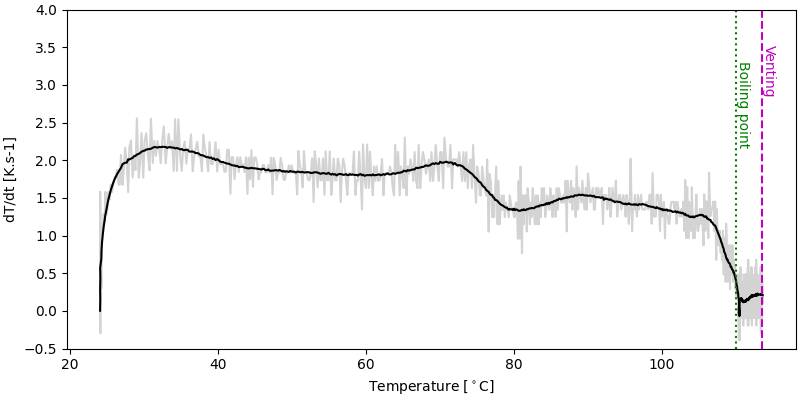

In [ ]:
dTdt_data = np.diff(data.Temp)/np.diff(data.t)
dT_filtered = signal.savgol_filter(dTdt_data, 50,3)

# plot 
fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
# ax = ax.flatten()
p1, = ax.plot(data.Temp[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
p2, = ax.plot(data.Temp[0:-1], dT_filtered, color = 'k', label = "Filtered dT/dt")
ax.set_ylabel("dT/dt [K.s-1]")
ax.set_xlabel("Temperature [$^\circ$C]")
ax.set_ylim([-0.5, 4])
# ax.set_xlim([0,])


if SOC_0 == 1:
    t_vent = data['t'].iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
    T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
    ylims = ax.get_ylim()
    ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = '--')
    ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.75+ ylims[0]), rotation=-90, color = 'm')
    ax.set_ylim(ylims) # keep original limits

T_bps = [110]
for T_bp in T_bps: 
    t_boiling = data.t[(T_bp-data.Temp)<0.2].iloc[0]
    ylims = ax.get_ylim()
    ax.plot([T_bp]*2, list(ylims), color = 'g', linestyle = ':')
    ax.annotate('Boiling point', xy=(T_bp, np.diff(ylims)*0.60+ ylims[0]), rotation=-90, color = 'g')


# Nondimensional

## Check that model runs

In [ ]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = P_dmc*0.7 + P_ec*0.3  
    return P

def sim_venting(k_sei, k_A):   
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Initial fraction of Li in SEI": 0.15*k_sei,
        "Frequency factor for SEI decomposition [s-1]": 2.25E15*k_A,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [ m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Initial cell compression stress [kPa]": data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        "Critical venting pressure [kPa]": max(158.7731,(max(data['F']) )/param['Active material surface area [m2]']/1000 + 101)
    }, check_already_exists = False)

    # Define input and output
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [T_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    k_b = pybamm.Scalar(constants.k)
    r_sei_dimensional = (
        -param.evaluate(thermal.A_sei)
        * x_sei
        * pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av))
    )  # units 1/s

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
        })

    # VENTING SUBMODEL
    P_crit = param.evaluate(thermal.P_crit)
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    sigma_0 = param.evaluate(thermal.sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    delta_d = L/E*delta_sigma
    T_amb = param.evaluate(thermal.T_amb_dim(0))
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    # P_dmc = 10**(6.4338-1413.0/(T_vol_av-44.25))
    # P_ec = 10**(6.4897-1836.57/(T_vol_av-102.23)) 
    # P_sat_e = P_dmc*0.7 + P_ec*0.3 
    P_sat_e = P_sat(T_vol_av)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    P_CO2 = pybamm.minimum(n_CO2*constants.R*T_vol_av/V_head/1000, P_crit) #kPa
    P_total =  P_CO2 + P_sat_e 

    model.variables.update({
        "Electrolyte gas saturation pressure [kPa]": P_sat_e,
        "CO2 gas pressure [kPa]": P_CO2,
        "Total gas pressure [kPa]": P_total,
    })

    # RHS
    model.rhs = {
        x_sei: r_sei_dimensional,
    }
    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_total-sigma_0-P_atm, E*alpha_cell*delta_T/L),
        }

    # set initial conditions
    model.initial_conditions = {
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        }

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # solve
    sim = pybamm.Simulation(model)
    for i,(t, T) in enumerate(zip(data.t[0:-1], data.Temp[0:-1]+273.15)):
        dt = data.t[i+1]-data.t[i]
        external_variables = {"Volume-averaged cell temperature [K]": T}
        sim.step(dt, external_variables=external_variables)

    return sim

sim = sim_venting(1,1) #0.1057 (100% t<80s), 0.04725 (75%)

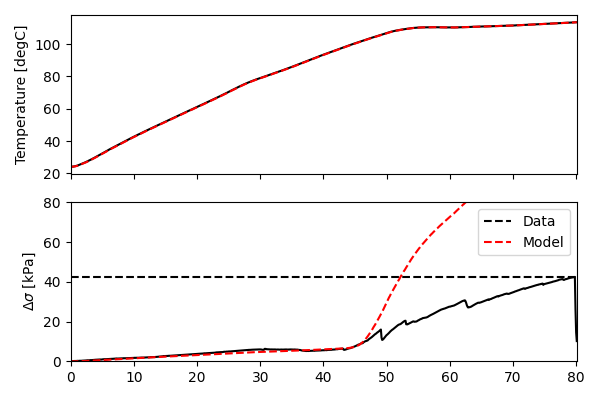

In [ ]:
sim = sim_venting(1,1) #0.1057 (100% t<80s), 0.04725 (75%)
solution = sim.solution
P_total = solution["Total gas pressure [kPa]"]
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
sigma = solution["Cell expansion stress [kPa]"](data.t)
data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0

# plot solution
data_color = 'k'
sim_color = 'r'
sim_ls = '--'

fig, ax= plt.subplots(2, 1, figsize=(6, 4), sharex = True)
ax.flatten()
ax[1].plot(data.t, data_sigma, color = data_color) 
ax[1].plot([data.t.iloc[0], data.t.iloc[-1]], 42.35277961*np.array([1,1]) , linestyle=sim_ls, color = data_color,  label = "Data") 
ax[1].plot(data.t, sigma,linestyle=sim_ls, color = sim_color, label = "Model")
ax[1].set_ylim([0,80])
ax[1].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
ax[1].set_ylabel("$\Delta \sigma$ [kPa]")
ax[1].legend()

T = solution["Volume-averaged cell temperature [K]"]
ax[0].plot(data.t, data.Temp, color = data_color) 
ax[0].plot(data.t, T(data.t)-273.15,linestyle=sim_ls, color = sim_color)
# ax[1].set_ylim([0,50])
# ax[1].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
ax[0].set_ylabel("Temperature [degC]")

plt.tight_layout()
plt.show()

## Set up loss function

In [ ]:
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)

def loss_stress(k:np.ndarray): 
    # k_sei = k[0]
    k_A = k[0]
    solution = sim_venting(1, k_A).solution

    # calculate squared sum for rest period
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    sigma = solution["Cell expansion stress [kPa]"](data.t)
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 -sigma_0  
    
    # loss_sigma = np.linalg.norm(data_sigma - sigma, ord = 1)
    loss_sigma = np.mean(np.square(data_sigma - sigma))
    # loss_T = np.linalg.norm((filtered_dTdt_data - dTdt_sim), ord = 1) + np.linalg.norm((data.Temp.iloc[0:-1] - T(t)), ord = 1)

    return np.array([loss_sigma])

# test function
print(loss_stress(np.array([1])))

[1370.49199924]


## Fit $A_{sei}$ parameter

In [14]:
# fit parameters 
# k0 = np.array([1,1]) # [k_sei, k_A]
# lb = np.array([0.1,0.1])
# ub = np.array([10,10])
# k = dfols.solve(loss_stress, k0, bounds = (lb,ub), rhoend=1e-4)
# update fitted thermal params
# k_sei = k.x[0]
# solution = sim_venting(k_sei, k_A).solution
# [k_sei, k_A] # k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s), k_A = 0.1146589 (MSE 1e-8 100% t<53s) ??
# [k_sei, k_A] # k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s) 

k0 = np.array([.1]) 
lb = np.array([0])
ub = np.array([1])
k = dfols.solve(loss_stress, k0, bounds = (lb,ub), rhoend=1e-8)
k_A = k.x[0]
solution = sim_venting(1,k_A).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states

print(k.x)


## Plot data vs model

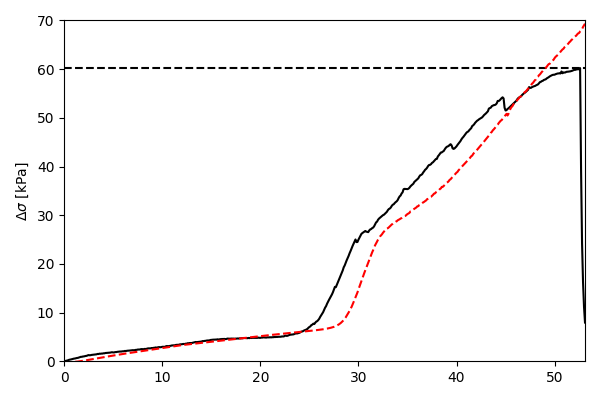

In [114]:
solution = sim_venting(1,k_A).solution
t_sol, y_sol = solution.t, solution.y  # get solution times and states
P_total = solution["Total gas pressure [kPa]"]

chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
sigma = solution["Cell expansion stress [kPa]"](data.t)
data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell

# plot solution
data_color = 'k'
sim_color = 'r'
sim_ls = '--'

fig, ax= plt.subplots(1, 1, figsize=(6, 4))
ax.plot(data.t, data_sigma, color = data_color) 
ax.plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=sim_ls, color = data_color) 
ax.plot(data.t, sigma,linestyle=sim_ls, color = sim_color)
ax.set_ylim([0,70])
ax.set_xlim([data.t.iloc[0], data.t.iloc[-1]])
ax.set_ylabel("$\Delta \sigma$ [kPa]")

plt.tight_layout()
plt.show()

# Archive

## Plot: Effect of $A_{sei}$ = $k_{A}A_{SEI,0}$

In [10]:
np.sum([0.09945129, 0.04428665, 0.06870394])/3

0.07081396000000001

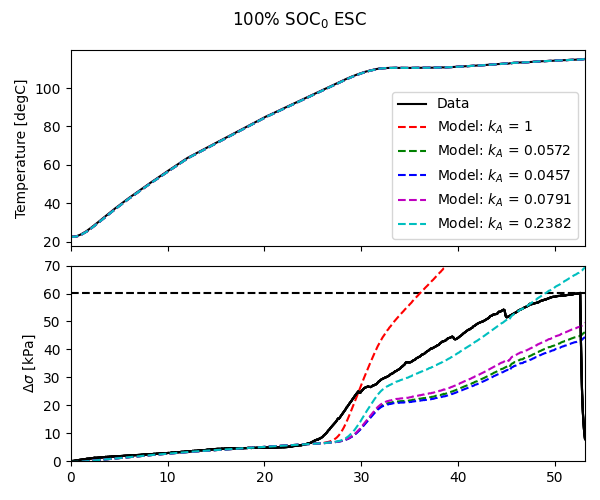

In [118]:
# k_As = [1, 0.09945129, 0.04428665, 0.06870394]# k_A = 0.06870394 (MSE 1e-8 50%), k_A = 0.04428665 (MSE 1e-8 75%), k_A = 0.09945129(MSE 1e-8 100% t<80s) MEAN = 0.07081396000000001
k_As = [1, 0.05716926, 0.04571944, 0.07912785, 0.238155]# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)
sim_colors = ['r', 'g', 'b', 'm', 'c']
fig, ax= plt.subplots(2, 1, figsize=(6, 5), sharex = True)
ax.flatten()
for i, k_A in enumerate(k_As): 
    solution = sim_venting(1,k_A).solution
    P_total = solution["Total gas pressure [kPa]"]

    chemistry = pybamm .parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
    sigma = solution["Cell expansion stress [kPa]"](data.t)
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 -sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell

    # plot solution
    data_color = 'k'
    sim_color = sim_colors[i]
    sim_ls = '--'

    T = solution["Volume-averaged cell temperature [K]"]
    if i ==0:
        ax[0].plot(data.t, data.Temp, color = data_color,  label = "Data") 
    ax[0].plot(data.t, T(data.t)-273.15,linestyle=sim_ls, color = sim_color, label = 'Model: $k_A$ = ' + str(round(k_A,  4)))
    # ax[1].set_ylim([0,50])
    # ax[1].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
    ax[0].set_ylabel("Temperature [degC]")
    ax[0].legend(loc = 'lower right')

    ax[1].plot(data.t, data_sigma, color = data_color) 
    if i ==0:
        ax[1].plot([data.t.iloc[0], data.t.iloc[-1]], sigma_max*np.array([1,1]) , linestyle=sim_ls, color = data_color,  label = "Data") 
    ax[1].plot(data.t, sigma,linestyle=sim_ls, color = sim_color, label = 'Model: $k_A$ = ' + str(k_A))
    ax[1].set_ylim([0,70])
    ax[1].set_xlim([data.t.iloc[0], data.t.iloc[-1]])
    ax[1].set_ylabel("$\Delta \sigma$ [kPa]")

fig.suptitle(str(int(SOC_0*100)) + "% SOC$_0$ ESC")
plt.tight_layout()
plt.show()